In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np




In [18]:
def dirichlet(d):
    Y=np.random.exponential(1,d)
    S=np.sum(Y)
    X=Y/S
    return X


# II. 1. 

In [19]:

def echantillon_dirichlet(n,d):
    X=np.zeros((n,d))
    for i in range(n):
        X[i]=dirichlet(d)
    return X

# II. 2.

In [20]:
def transformation_T(u_vector, d):
    """
    Transforme un vecteur u de taille d-1 (du carré) 
    en un vecteur x de taille d (sur le simplexe).
    """
    x = np.zeros(d) # Vecteur 1D de taille d (pas d+1, pas 2D)
    somme_x_precedents = 0.0
    
    # On calcule les d-1 premières coordonnées
    # u_vector indices : 0 à d-2
    for k in range(1, d): 
        # k va de 1 à d-1 (indices mathématiques du sujet)
        
        # On récupère u_k (indice k-1 en Python)
        u_val = u_vector[k-1] 
        
        # Formule du sujet 
        puissance = 1.0 / (d - k)
        valeur_x = (1 - somme_x_precedents) * (1 - u_val**puissance)
        
        x[k-1] = valeur_x # On stocke x_k à l'indice k-1
        somme_x_precedents += valeur_x # On met à jour la somme
        
    # La dernière coordonnée 
    x[d-1] = 1 - somme_x_precedents
    
    return x

In [21]:
def echantillon_hypercube(n, d):
    # A. Génération LHS sur le carré [0,1]^(d-1)
    # On doit générer n points d'un coup pour garantir la stratification
    dim_u = d - 1
    U = np.zeros((n, dim_u))
    
    for j in range(dim_u):
        # Pour chaque dimension, on divise en n intervalles
        points = (np.arange(n) + np.random.rand(n)) / n
        np.random.shuffle(points) # On mélange
        U[:, j] = points
        
    # B. Transformation de chaque point
    X = np.zeros((n, d))
    for i in range(n):
        X[i, :] = transformation_T(U[i, :], d)
        
    return X

# II. 3.

Affichage pour n=10 :


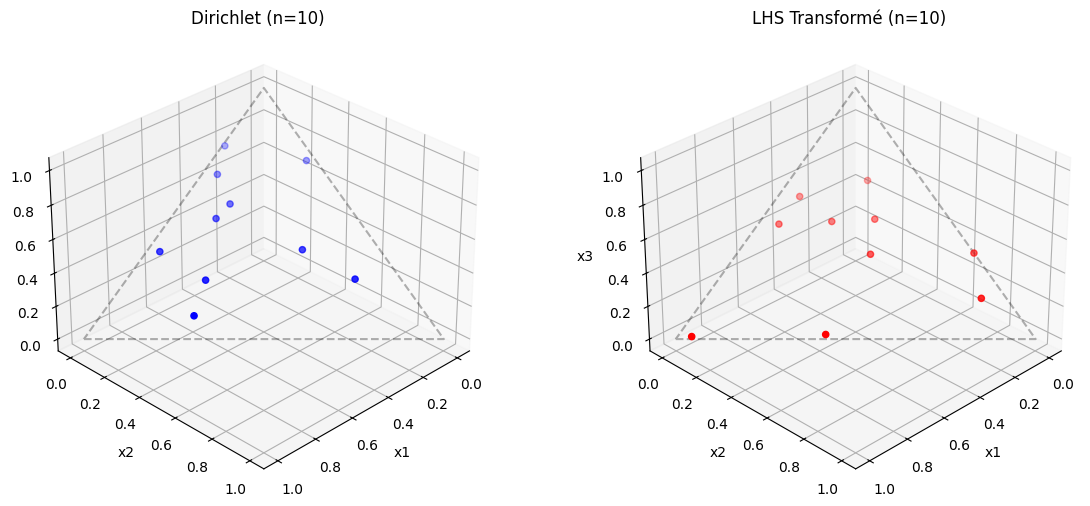

Affichage pour n=50 :


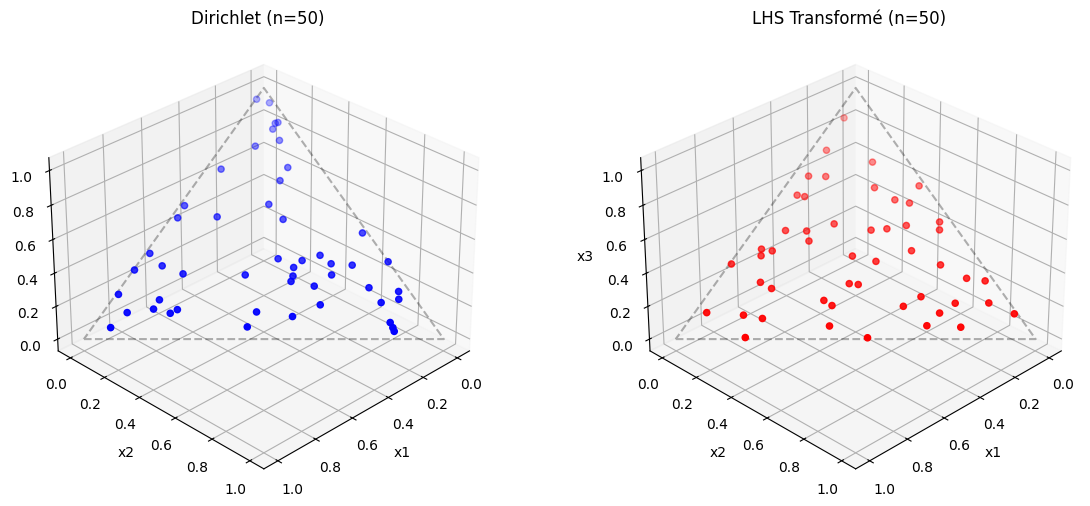

In [22]:

def afficher_comparaison(n, d=3):
    X_dirichlet = echantillon_dirichlet(n, d)
    X_lhs = echantillon_hypercube(n, d)
    
    fig = plt.figure(figsize=(14, 6))
    
    # Graphique 1 : Dirichlet 
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(X_dirichlet[:, 0], X_dirichlet[:, 1], X_dirichlet[:, 2], c='blue', label='Points')
    
    # Astuce visuelle : tracer le contour du triangle (simplexe) pour mieux voir
    ax1.plot([1,0,0,1], [0,1,0,0], [0,0,1,0], 'k--', alpha=0.3)
    ax1.set_title(f"Dirichlet (n={n})")
    ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('x3')
    ax1.view_init(elev=30, azim=45) # Meilleur angle de vue

    # Graphique 2 : Hypercube Latin Transformé ---
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(X_lhs[:, 0], X_lhs[:, 1], X_lhs[:, 2], c='red', label='Points')
    
    # Contour du triangle
    ax2.plot([1,0,0,1], [0,1,0,0], [0,0,1,0], 'k--', alpha=0.3)
    ax2.set_title(f"LHS Transformé (n={n})")
    ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
    ax2.view_init(elev=30, azim=45)

    plt.show()


print("Affichage pour n=10 :")
afficher_comparaison(n=10, d=3)

print("Affichage pour n=50 :")
afficher_comparaison(n=50, d=3)

# II. 4.

1. Étude variation de n (d=3)...
2. Étude variation de d (n=50)...


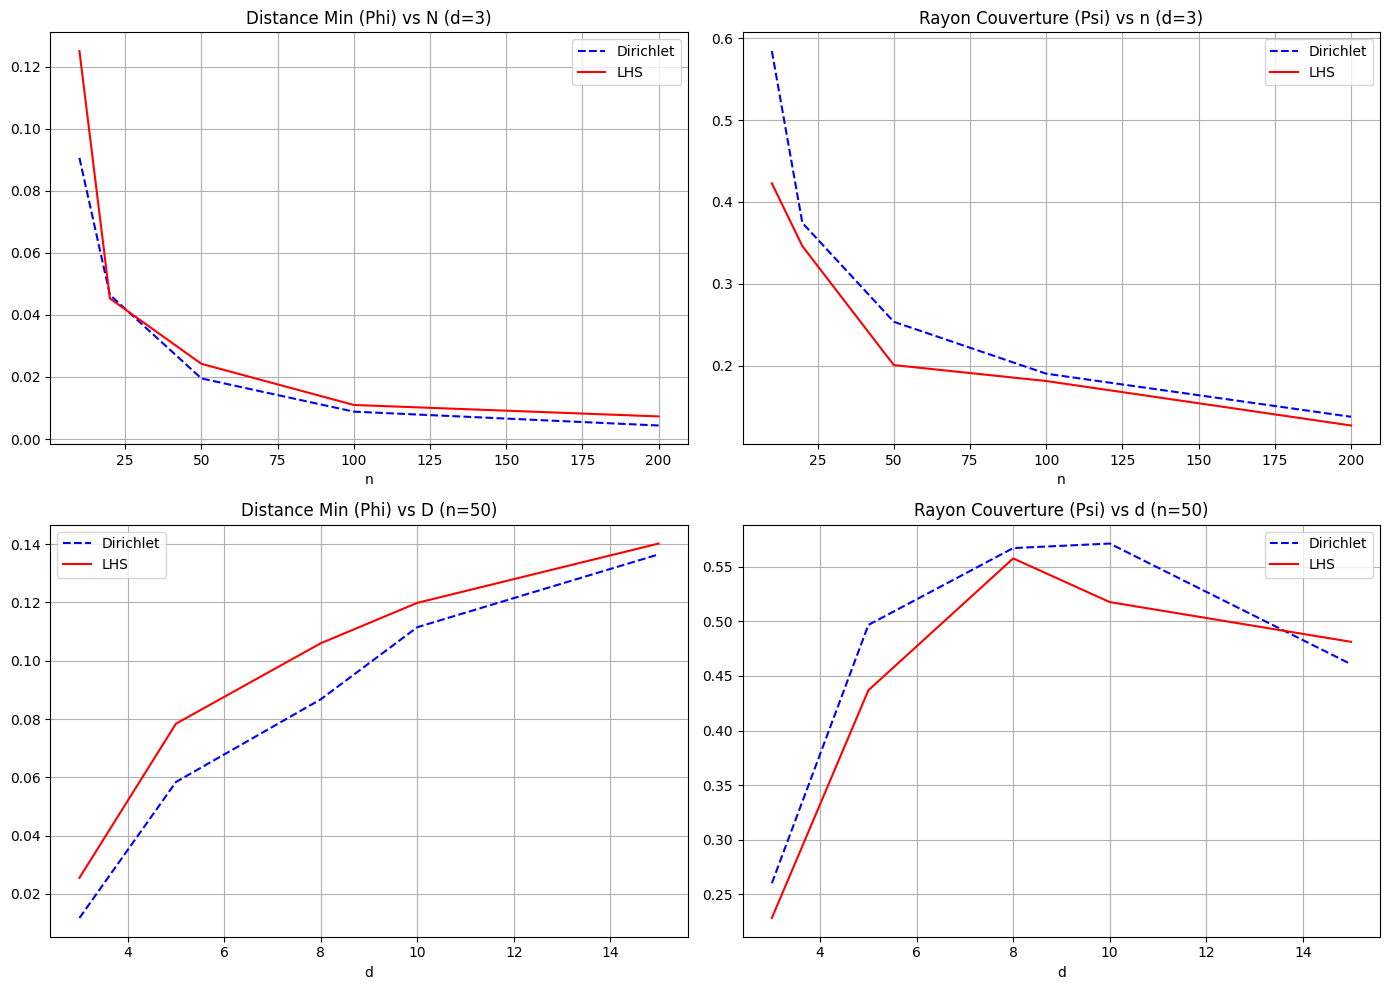

In [ ]:
from scipy.spatial.distance import pdist, cdist

def calcul_phi(X):
    if len(X) < 2: return 0
    return np.min(pdist(X, metric='euclidean'))

def calcul_psi(X, d, n_test=150000):
    # Pour étudier d grand, il faut assez de points de test
    # n_test=50000 peut être un compromis vitesse/précision
    #on choisit cette approche pour éviter d'éventuels minima locaux qui pourrait apparaitre avec scipy.optimize(on n'a pas la convexité et encore moins la dérivabilité de la fonction)
    Y_test = np.random.exponential(1, (n_test, d))
    Y_test = Y_test / Y_test.sum(axis=1, keepdims=True)
    dists = cdist(Y_test, X, metric='euclidean')
    return np.max(np.min(dists, axis=1))

# 3. Étude Complète (n et d)
def etude_complete():
    # A. Etude en fonction de n (à d fixé = 3)
    d_fixe = 3
    valeurs_n = [10, 20, 50, 100, 200]
    
    res_n = {'phi_dir': [], 'psi_dir': [], 'phi_lhs': [], 'psi_lhs': []}
    
    print(f"1. Étude variation de n (d={d_fixe})...")
    for n in valeurs_n:
        # On moyenne sur 5 essais
        phi_d, psi_d, phi_l, psi_l = [], [], [], []
        for _ in range(5):
            Xd = echantillon_dirichlet(n, d_fixe)
            Xl = echantillon_hypercube(n, d_fixe)
            phi_d.append(calcul_phi(Xd)); psi_d.append(calcul_psi(Xd, d_fixe))
            phi_l.append(calcul_phi(Xl)); psi_l.append(calcul_psi(Xl, d_fixe))
            
        res_n['phi_dir'].append(np.mean(phi_d)); res_n['psi_dir'].append(np.mean(psi_d))
        res_n['phi_lhs'].append(np.mean(phi_l)); res_n['psi_lhs'].append(np.mean(psi_l))

    # B. Etude en fonction de d (à n fixé = 50)
    n_fixe = 50
    valeurs_d = [3, 5, 8, 10, 15]
    
    res_d = {'phi_dir': [], 'psi_dir': [], 'phi_lhs': [], 'psi_lhs': []}
    
    print(f"2. Étude variation de d (n={n_fixe})...")
    for d in valeurs_d:
        phi_d, psi_d, phi_l, psi_l = [], [], [], []
        for _ in range(5):
            Xd = echantillon_dirichlet(n_fixe, d)
            Xl = echantillon_hypercube(n_fixe, d)
            phi_d.append(calcul_phi(Xd)); psi_d.append(calcul_psi(Xd, d))
            phi_l.append(calcul_phi(Xl)); psi_l.append(calcul_psi(Xl, d))
            
        res_d['phi_dir'].append(np.mean(phi_d)); res_d['psi_dir'].append(np.mean(psi_d))
        res_d['phi_lhs'].append(np.mean(phi_l)); res_d['psi_lhs'].append(np.mean(psi_l))

    # Affichage 2x2
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    # Ligne 1 : Variation de n
    axs[0,0].plot(valeurs_n, res_n['phi_dir'], 'b--', label='Dirichlet')
    axs[0,0].plot(valeurs_n, res_n['phi_lhs'], 'r-', label='LHS')
    axs[0,0].set_title(f'Distance Min (Phi) vs N (d={d_fixe})')
    axs[0,0].set_xlabel('n'); axs[0,0].grid(True); axs[0,0].legend()

    axs[0,1].plot(valeurs_n, res_n['psi_dir'], 'b--', label='Dirichlet')
    axs[0,1].plot(valeurs_n, res_n['psi_lhs'], 'r-', label='LHS')
    axs[0,1].set_title(f'Rayon Couverture (Psi) vs n (d={d_fixe})')
    axs[0,1].set_xlabel('n'); axs[0,1].grid(True); axs[0,1].legend()

    # Ligne 2 : Variation de D
    axs[1,0].plot(valeurs_d, res_d['phi_dir'], 'b--', label='Dirichlet')
    axs[1,0].plot(valeurs_d, res_d['phi_lhs'], 'r-', label='LHS')
    axs[1,0].set_title(f'Distance Min (Phi) vs D (n={n_fixe})')
    axs[1,0].set_xlabel('d'); axs[1,0].grid(True); axs[1,0].legend()

    axs[1,1].plot(valeurs_d, res_d['psi_dir'], 'b--', label='Dirichlet')
    axs[1,1].plot(valeurs_d, res_d['psi_lhs'], 'r-', label='LHS')
    axs[1,1].set_title(f'Rayon Couverture (Psi) vs d (n={n_fixe})')
    axs[1,1].set_xlabel('d'); axs[1,1].grid(True); axs[1,1].legend()
    
    plt.tight_layout()
    plt.show()

etude_complete()

### Analyse des Résultats : Aléatoire Pur vs Stratifié

Cette section compare deux méthodes d'échantillonnage stochastiques sur le simplexe :
1. **Dirichlet** : Une approche par **hasard pur** (Monte Carlo classique).
2. **LHS Transformé** : Une approche par **hasard stratifié** (Latin Hypercube Sampling).

Nous évaluons la qualité du remplissage de l'espace via deux critères : la distance minimale ($\phi$, critère de *packing*) et le rayon de couverture ($\psi$, critère de *covering*).

#### 1. L'impact du nombre de points ($n$)
*À dimension fixée ($d=3$), nous faisons varier le nombre de points.*

* **Distance Minimale ($\phi$) :** La courbe **LHS (rouge)** reste quasi-systématiquement **au-dessus** de celle de Dirichlet.
    * *Interprétation :* Bien que les deux méthodes soient aléatoires, le LHS impose des **contraintes structurelles** (stratification). Cela empêche les points de se "marcher dessus" et évite les amas typiques du hasard pur.

* **Rayon de Couverture ($\psi$) :** La courbe **LHS** est **en dessous** de Dirichlet.
    * *Interprétation :* En forçant la répartition sur une grille avant transformation, le LHS assure une occupation plus homogène du volume et réduit la taille des zones vides ("trous").

**Bilan :** Le LHS est une technique de **réduction de variance**. À budget égal ($n$ points), il offre une meilleure représentativité que le tirage indépendant.

---

#### 2. L'impact de la dimension ($d$) : La Malédiction de la Dimension
*À nombre de points fixé ($n=50$), nous faisons varier la dimension.*

* **Distance Minimale ($\phi$) :** Elle augmente avec la dimension.
    * *Intuition :* Dans un espace de grande dimension, les points sont statistiquement isolés sur les bords du simplexe, augmentant la distance moyenne entre eux.

* **Rayon de Couverture ($\psi$) :** Le rayon **augmente drastiquement** dès que $d$ dépasse 5 ou 6.
    * *Intuition :* C'est la **« Malédiction de la Dimension »** (*Curse of Dimensionality*). Le volume explose exponentiellement avec $d$. Même avec une méthode stratifiée comme le LHS, 50 points deviennent insuffisants pour couvrir un espace de dimension 15.

#### Conclusion
Le **LHS** est supérieur au tirage aléatoire simple car il introduit de l'ordre dans le hasard. Cependant, aucune méthode d'échantillonnage ne peut compenser l'explosion du volume en haute dimension sans augmenter massivement le nombre de points.

# III. 2.

--- Démarrage Optimisation (n=10, d=3) ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.2617969732841276
            Iterations: 19
            Function evaluations: 27
            Gradient evaluations: 19
Distance Min Finale : 0.2618


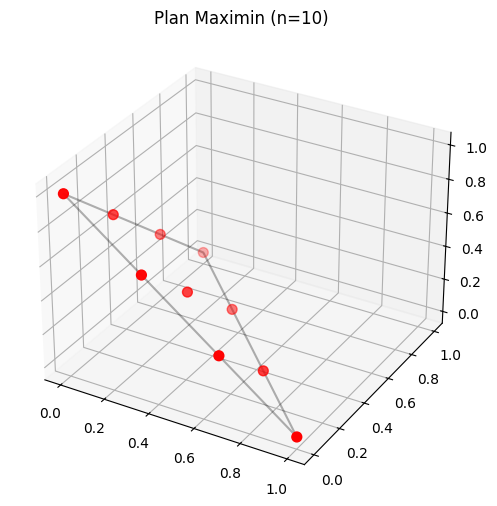

--- Démarrage Optimisation (n=50, d=3) ---
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.05928461952984632
            Iterations: 33
            Function evaluations: 59
            Gradient evaluations: 33
Distance Min Finale : 0.0593


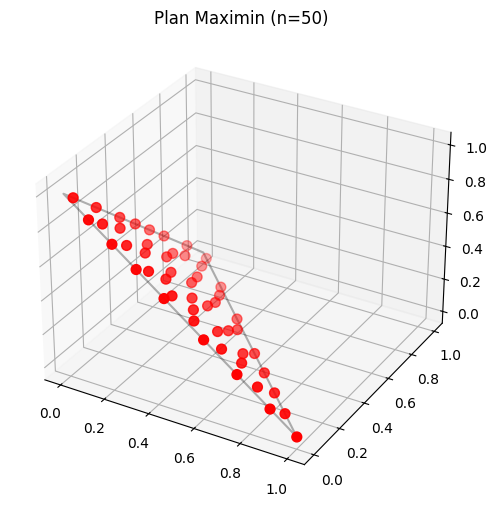

In [ ]:
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Fonctions du critère lissé (phi_p) 
def phi_p(X_flat, n, d, p=50):
    X = X_flat.reshape((n, d))
    dists = pdist(X)
    dists = np.maximum(dists, 1e-10) # Évite division par 0
    return np.sum(dists**(-p))**(-1.0/p)

def grad_phi_p(X_flat, n, d, p=50):
    X = X_flat.reshape((n, d))
    grad = np.zeros_like(X)
    dists = pdist(X)
    dists = np.maximum(dists, 1e-10)
    
    # Terme commun : phi(X)^(p+1)
    phi_val = np.sum(dists**(-p))**(-1.0/p)
    factor = phi_val**(p+1)
    
    # Matrice des distances carrees
    dist_matrix = squareform(dists)
    # M_ij = ||x_i - x_j||^(-p-2)
    with np.errstate(divide='ignore'):
        M = dist_matrix**(-p-2)
    np.fill_diagonal(M, 0)
    
    for k in range(n):
        diffs = X[k] - X 
        # On pondère chaque vecteur différence par M[k, j]
        weighted_diffs = diffs * M[k][:, np.newaxis]
        grad[k] = factor * np.sum(weighted_diffs, axis=0)
        
    return grad.flatten()

#  2. Fonction d'optimisation
def optimiser_maximin(n=10, d=3, p=10):
    print(f"--- Démarrage Optimisation (n={n}, d={d}) ---")
    
    # Point de départ : Un bon LHS ou aléatoire
    x0 = np.random.rand(n, d)
    # Projection sur le simplexe 
    x0 = x0 / x0.sum(axis=1, keepdims=True)
    x0_flat = x0.flatten()
    
    # Contraintes : Somme = 1
    constraints = []
    for i in range(n):
        def constraint_sum(x_flat, idx=i):
            x = x_flat.reshape((n, d))
            return np.sum(x[idx]) - 1.0
        constraints.append({'type': 'eq', 'fun': constraint_sum})
        
    # Bornes : 0 <= x <= 1
    bounds = [(0, 1) for _ in range(n*d)]
    
    # Minimiser l'opposé de la distance (-phi_p) pour maximiser phi_p
    res = minimize(lambda x: -phi_p(x, n, d, p), 
                   x0_flat, 
                   method='SLSQP', 
                   jac=lambda x: -grad_phi_p(x, n, d, p),
                   bounds=bounds,
                   constraints=constraints,
                   options={'maxiter': 1000, 'ftol': 1e-4, 'disp': True})
    
    X_opt = res.x.reshape((n, d))
    print(f"Distance Min Finale : {phi_p(res.x, n, d, p):.4f}")
    return X_opt

# 3. Lancement 
n_points = 10  
d_dim = 3

X_final = optimiser_maximin(n=n_points, d=d_dim, p=5)

# 4. Affichage 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_final[:,0], X_final[:,1], X_final[:,2], c='red', s=50, label='Maximin Optimisé')
# Cadre du simplexe
ax.plot([1,0,0,1], [0,1,0,0], [0,0,1,0], 'k-', alpha=0.3)
ax.set_title(f"Plan Maximin (n={n_points})")
plt.show()

n_points = 50

X_final = optimiser_maximin(n=n_points, d=d_dim, p=5)

# 4. Affichage 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_final[:,0], X_final[:,1], X_final[:,2], c='red', s=50, label='Maximin Optimisé')
# Cadre du simplexe
ax.plot([1,0,0,1], [0,1,0,0], [0,0,1,0], 'k-', alpha=0.3)
ax.set_title(f"Plan Maximin (n={n_points})")
plt.show()

# III. 3.

1. Étude variation de N (d=3)...
  Optimisation n=10...
  Optimisation n=20...
  Optimisation n=30...
  Optimisation n=40...
2. Étude variation de D (n=20)...
  Optimisation d=3...
  Optimisation d=4...
  Optimisation d=5...
  Optimisation d=6...


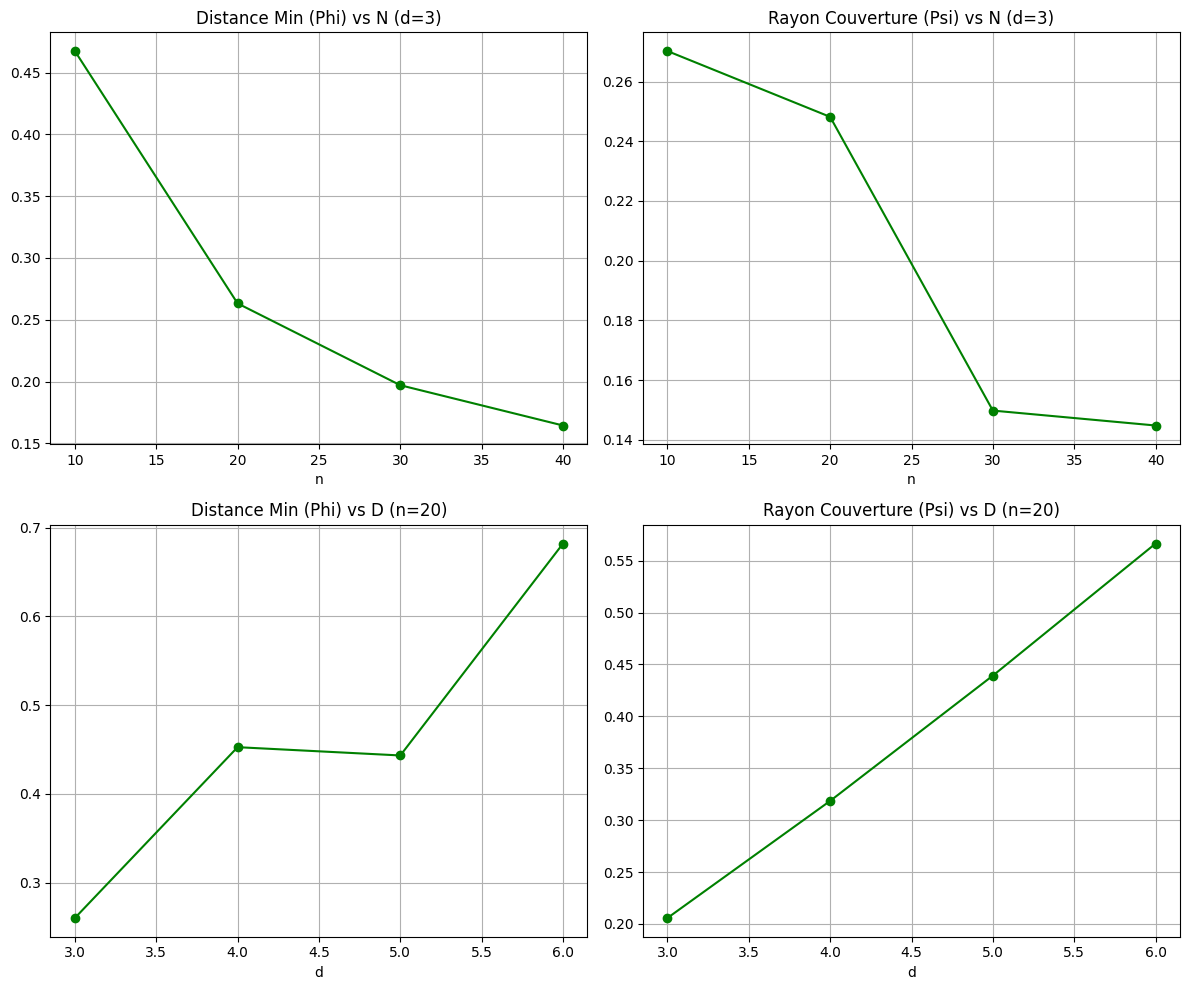

In [ ]:
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform, cdist

# 1. Rappel des Fonctions Nécessaires 

def phi_p(X_flat, n, d, p):
    X = X_flat.reshape((n, d))
    dists = pdist(X)
    dists = np.maximum(dists, 1e-10)
    return np.sum(dists**(-p))**(-1.0/p)

def grad_phi_p(X_flat, n, d, p):
    X = X_flat.reshape((n, d))
    grad = np.zeros_like(X)
    dists = pdist(X)
    dists = np.maximum(dists, 1e-10)
    phi_val = np.sum(dists**(-p))**(-1.0/p)
    factor = phi_val**(p+1)
    dist_matrix = squareform(dists)
    with np.errstate(divide='ignore'):
        M = dist_matrix**(-p-2)
    np.fill_diagonal(M, 0)
    for k in range(n):
        weighted_diffs = (X[k] - X) * M[k][:, np.newaxis]
        grad[k] = factor * np.sum(weighted_diffs, axis=0)
    return grad.flatten()

def optimiser_maximin(n, d, p=10):
    # Initialisation LHS (pour aider l'algo)
    # (Ici simplifié par un random pour que le code soit autonome)
    x0 = np.random.rand(n, d)
    x0 = x0 / x0.sum(axis=1, keepdims=True)
    
    constraints = [{'type': 'eq', 'fun': lambda x, i=i: np.sum(x.reshape((n,d))[i]) - 1} for i in range(n)]
    bounds = [(0, 1) for _ in range(n*d)]
    
    # On minimise -phi_p pour maximiser la distance
    res = minimize(lambda x: -phi_p(x, n, d, p), 
                   x0.flatten(), 
                   method='SLSQP', 
                   jac=lambda x: -grad_phi_p(x, n, d, p),
                   bounds=bounds,
                   constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-4})
    return res.x.reshape((n, d))

# Métriques réelles (Phi = min dist, Psi = rayon)
def get_metrics(X, d):
    phi = np.min(pdist(X))
    # Monte Carlo pour Psi
    Y_test = np.random.exponential(1, (2000, d))
    Y_test = Y_test / Y_test.sum(axis=1, keepdims=True)
    psi = np.max(np.min(cdist(Y_test, X), axis=1))
    return phi, psi

# 2. Lancement de l'Étude 

def etude_empirique_optimisation():
    # Paramètres réduits pour que ça ne tourne pas 1h
    n_values = [10, 20, 30, 40] 
    d_fixe = 3
    
    d_values = [3, 4, 5, 6]
    n_fixe = 20
    
    p_param = 10 # "p assez grand"

    res_n = {'phi': [], 'psi': []}
    res_d = {'phi': [], 'psi': []}
    
    print("1. Étude variation de N (d=3)...")
    for n in n_values:
        print(f"  Optimisation n={n}...")
        X_opt = optimiser_maximin(n, d_fixe, p=p_param)
        phi, psi = get_metrics(X_opt, d_fixe)
        res_n['phi'].append(phi)
        res_n['psi'].append(psi)

    print("2. Étude variation de D (n=20)...")
    for d in d_values:
        print(f"  Optimisation d={d}...")
        X_opt = optimiser_maximin(n_fixe, d, p=p_param)
        phi, psi = get_metrics(X_opt, d)
        res_d['phi'].append(phi)
        res_d['psi'].append(psi)

    # 3. Affichage
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # Variation N
    axs[0,0].plot(n_values, res_n['phi'], 'g-o', label='Maximin Optimisé')
    axs[0,0].set_title(f'Distance Min (Phi) vs N (d={d_fixe})')
    axs[0,0].set_xlabel('n'); axs[0,0].grid(True)
    
    axs[0,1].plot(n_values, res_n['psi'], 'g-o', label='Maximin Optimisé')
    axs[0,1].set_title(f'Rayon Couverture (Psi) vs N (d={d_fixe})')
    axs[0,1].set_xlabel('n'); axs[0,1].grid(True)

    # Variation D
    axs[1,0].plot(d_values, res_d['phi'], 'g-o', label='Maximin Optimisé')
    axs[1,0].set_title(f'Distance Min (Phi) vs D (n={n_fixe})')
    axs[1,0].set_xlabel('d'); axs[1,0].grid(True)

    axs[1,1].plot(d_values, res_d['psi'], 'g-o', label='Maximin Optimisé')
    axs[1,1].set_title(f'Rayon Couverture (Psi) vs D (n={n_fixe})')
    axs[1,1].set_xlabel('d'); axs[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()

etude_empirique_optimisation()

# IV. 2. 

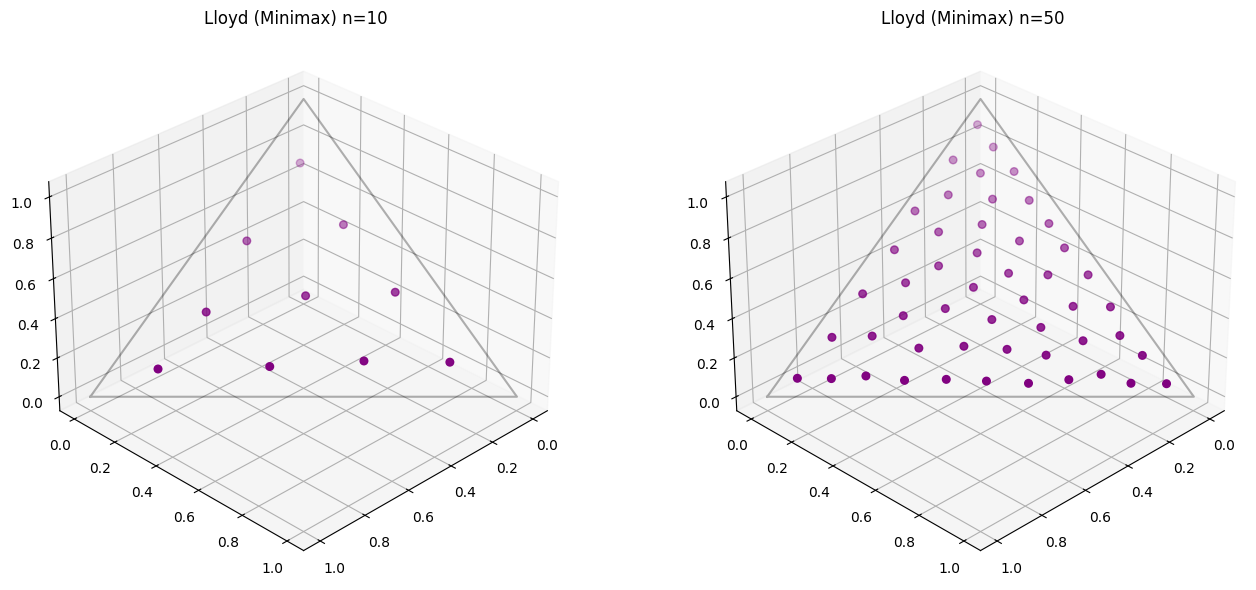

In [26]:


def echantillon_dirichlet(n, d):
    Y = np.random.exponential(1, (n, d))
    return Y / Y.sum(axis=1, keepdims=True)

def algorithme_lloyd(n, d, n_iter=20, n_grid=20000):
    X = echantillon_dirichlet(n, d)
    
    Grid = echantillon_dirichlet(n_grid, d)
    
    for _ in range(n_iter):
        dists = cdist(Grid, X)
        labels = np.argmin(dists, axis=1)
        
        X_new = np.zeros_like(X)
        for j in range(n):
            mask = (labels == j)
            if np.any(mask):
                X_new[j] = np.mean(Grid[mask], axis=0)
            else:
                X_new[j] = X[j] 
        X = X_new
        
    return X

def afficher_lloyd(n_values, d=3):
    fig = plt.figure(figsize=(14, 6))
    
    for i, n in enumerate(n_values):
        X_lloyd = algorithme_lloyd(n, d)
        
        ax = fig.add_subplot(1, 2, i+1, projection='3d')
        ax.scatter(X_lloyd[:, 0], X_lloyd[:, 1], X_lloyd[:, 2], c='purple', s=30)
        ax.plot([1,0,0,1], [0,1,0,0], [0,0,1,0], 'k-', alpha=0.3)
        ax.set_title(f"Lloyd (Minimax) n={n}")
        ax.view_init(elev=30, azim=45)
        
    plt.tight_layout()
    plt.show()

afficher_lloyd([10, 50])

# IV. 3.

1. Variation de N (d=3)...
  n=10...
  n=20...
  n=30...
  n=40...
2. Variation de D (n=20)...
  d=3...
  d=4...
  d=5...
  d=6...


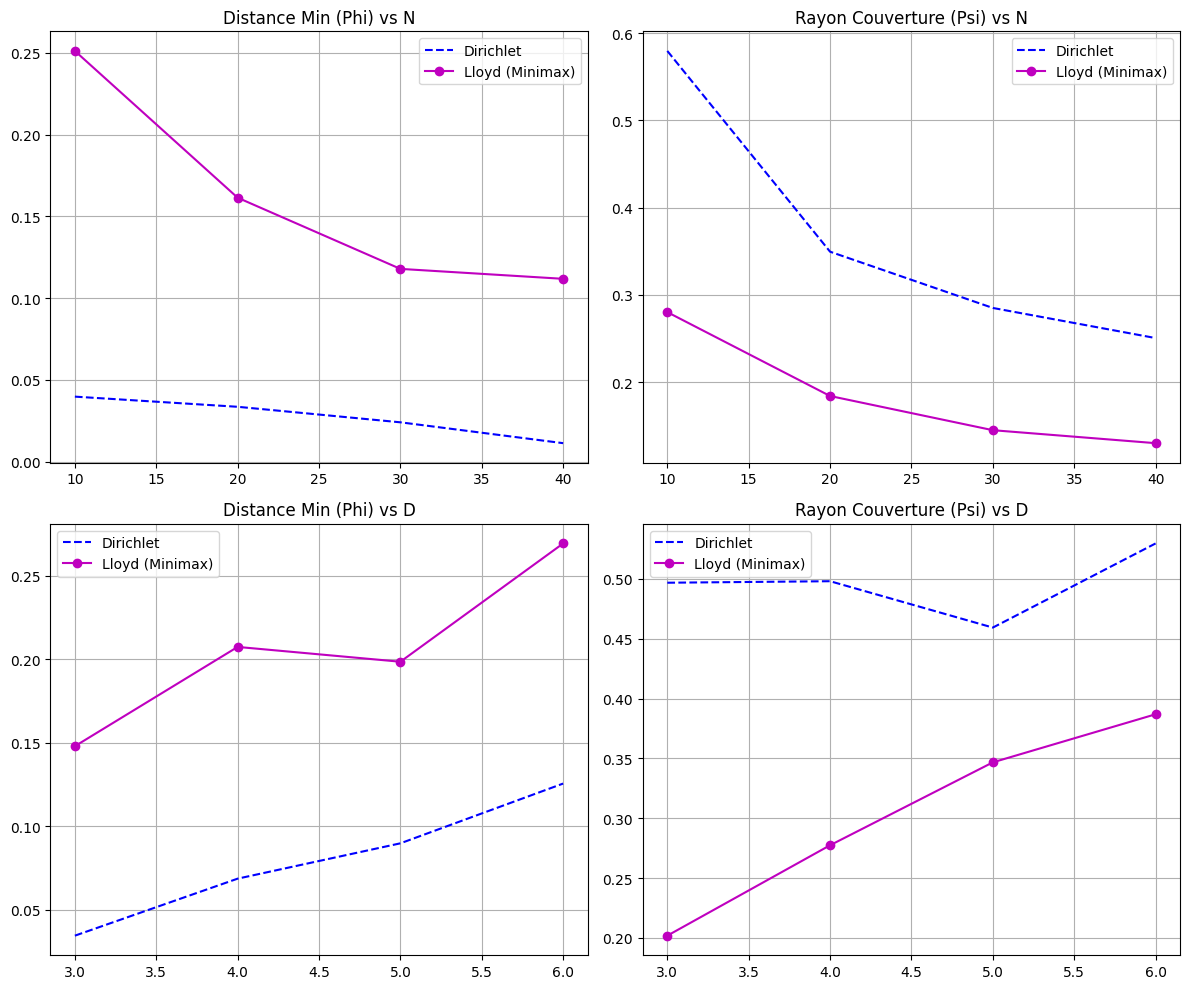

In [27]:

# Rappel des fonctions nécessaires
def echantillon_dirichlet(n, d):
    Y = np.random.exponential(1, (n, d))
    return Y / Y.sum(axis=1, keepdims=True)

def calcul_phi(X): # Distance min
    if len(X) < 2: return 0
    return np.min(pdist(X))

def calcul_psi(X, d, n_test=5000): # Rayon de couverture
    Y_test = echantillon_dirichlet(n_test, d)
    dists = cdist(Y_test, X)
    return np.max(np.min(dists, axis=1))

def algorithme_lloyd(n, d, n_iter=10, n_grid=10000):
    X = echantillon_dirichlet(n, d)
    Grid = echantillon_dirichlet(n_grid, d)
    for _ in range(n_iter):
        dists = cdist(Grid, X)
        labels = np.argmin(dists, axis=1)
        X_new = np.zeros_like(X)
        for j in range(n):
            mask = (labels == j)
            if np.any(mask):
                X_new[j] = np.mean(Grid[mask], axis=0)
            else:
                X_new[j] = X[j]
        X = X_new
    return X

# Étude Empirique 
def etude_lloyd_finale():
    # Paramètres
    n_values = [10, 20, 30, 40]
    d_fixe = 3
    
    d_values = [3, 4, 5, 6]
    n_fixe = 20
    
    # Stockage
    res_n = {'phi_init': [], 'psi_init': [], 'phi_lloyd': [], 'psi_lloyd': []}
    res_d = {'phi_init': [], 'psi_init': [], 'phi_lloyd': [], 'psi_lloyd': []}
    
    print("1. Variation de N (d=3)...")
    for n in n_values:
        print(f"  n={n}...")
        # Avant Lloyd (Dirichlet)
        X_init = echantillon_dirichlet(n, d_fixe)
        res_n['phi_init'].append(calcul_phi(X_init))
        res_n['psi_init'].append(calcul_psi(X_init, d_fixe))
        
        # Après Lloyd
        X_lloyd = algorithme_lloyd(n, d_fixe, n_iter=10)
        res_n['phi_lloyd'].append(calcul_phi(X_lloyd))
        res_n['psi_lloyd'].append(calcul_psi(X_lloyd, d_fixe))

    print("2. Variation de D (n=20)...")
    for d in d_values:
        print(f"  d={d}...")
        # Avant Lloyd
        X_init = echantillon_dirichlet(n_fixe, d)
        res_d['phi_init'].append(calcul_phi(X_init))
        res_d['psi_init'].append(calcul_psi(X_init, d))
        
        # Après Lloyd
        X_lloyd = algorithme_lloyd(n_fixe, d, n_iter=10)
        res_d['phi_lloyd'].append(calcul_phi(X_lloyd))
        res_d['psi_lloyd'].append(calcul_psi(X_lloyd, d))

    # --- Affichage ---
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # Ligne 1 : Variation N
    axs[0,0].plot(n_values, res_n['phi_init'], 'b--', label='Dirichlet')
    axs[0,0].plot(n_values, res_n['phi_lloyd'], 'm-o', label='Lloyd (Minimax)')
    axs[0,0].set_title('Distance Min (Phi) vs N')
    axs[0,0].legend(); axs[0,0].grid(True)
    
    axs[0,1].plot(n_values, res_n['psi_init'], 'b--', label='Dirichlet')
    axs[0,1].plot(n_values, res_n['psi_lloyd'], 'm-o', label='Lloyd (Minimax)')
    axs[0,1].set_title('Rayon Couverture (Psi) vs N')
    axs[0,1].legend(); axs[0,1].grid(True)
    
    # Ligne 2 : Variation D
    axs[1,0].plot(d_values, res_d['phi_init'], 'b--', label='Dirichlet')
    axs[1,0].plot(d_values, res_d['phi_lloyd'], 'm-o', label='Lloyd (Minimax)')
    axs[1,0].set_title('Distance Min (Phi) vs D')
    axs[1,0].legend(); axs[1,0].grid(True)
    
    axs[1,1].plot(d_values, res_d['psi_init'], 'b--', label='Dirichlet')
    axs[1,1].plot(d_values, res_d['psi_lloyd'], 'm-o', label='Lloyd (Minimax)')
    axs[1,1].set_title('Rayon Couverture (Psi) vs D')
    axs[1,1].legend(); axs[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()

etude_lloyd_finale()